![Alt text: Slogan da Meteora.](https://i.imgur.com/VDYh2G1.png)

# 1. Estruturando a tabela

**Meteora** é uma loja que vende roupas e acessórios de diversas marcas por todos os estados do Brasil, para entender suas bases de dados e exibir informações relevantes com o objetivo de auxiliar suas tomadas de decisão.

In [2]:
import pandas as pd
import matplotlib as plt
from sqlalchemy import create_engine, inspect, text

Sobre as tabelas

itens_pedidos: tabela que informa sobre o que foi vendido, vai ter informação o preço, quantidade, para onde vai ser enviado e o frete do pedido
pedidos: vai falar sobre a venda feita, tendo informação sobre os vendedores, preço do pedido e a data da venda
produtos: informa características dos produtos que são comercializados na loja
vendedores: informa o nome dos vendedores.

In [3]:
url_itens_pedidos = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/itens_pedidos.csv'
url_pedidos = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/pedidos.csv'
url_produto = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/produtos.csv'
url_vendedores = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/vendedores.csv'

In [4]:
itens_pedidos = pd.read_csv(url_itens_pedidos) 
pedidos = pd.read_csv(url_pedidos)
produtos = pd.read_csv(url_produto)
vendedores = pd.read_csv(url_vendedores)

In [5]:
engine = create_engine('sqlite:///:memory:')

In [6]:
produtos.to_sql('produtos',engine,index=False)

205

In [7]:
itens_pedidos.to_sql('itens_pedidos', engine, index=False)
pedidos.to_sql('pedidos', engine, index=False)
vendedores.to_sql('vendedores', engine, index=False)

5

In [8]:
inspector = inspect(engine)
print(inspector.get_table_names())

['itens_pedidos', 'pedidos', 'produtos', 'vendedores']


# 2. Primeiras consultas

Vamos entender a característica do produto que é comercializadora na Meteora, analisando a **condição** dos produtos vendidos.

In [9]:
query = 'SELECT CONDICAO FROM PRODUTOS'

In [10]:
with engine.connect() as conexao: 
    consulta = conexao.execute(text(query))
    dados = consulta.fetchall()
pd.DataFrame(dados, columns=consulta.keys())



,Condicao
0,Usado
1,Usado
2,Usado
3,Usado
4,Usado
...,...
200,Usado
201,Usado
202,Usado
203,Usado


In [11]:
def sql_df(query): 
    with engine.connect() as conexao: 
        consulta = conexao.execute(text(query))
        dados = consulta.fetchall()
    return pd.DataFrame(dados, columns=consulta.keys())

In [12]:
query = '''SELECT CONDICAO, COUNT(*) AS 'Quantidade'
FROM PRODUTOS 
GROUP BY CONDICAO;'''
df_produtos = sql_df(query)
df_produtos

,Condicao,Quantidade
0,Novo com etiqueta,22
1,Novo sem etiqueta,7
2,Usado,176


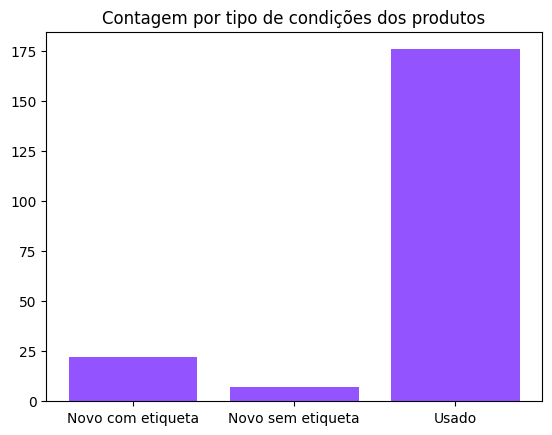

In [13]:
import matplotlib.pyplot as plt

plt.bar(df_produtos['Condicao'], df_produtos['Quantidade'], color='#9353FF')
plt.title('Contagem por tipo de condições dos produtos')
plt.show()

Agora precisamos ranquear os produtos que mais foram pedidos por **quantidade** para entender a necessidade de um estoque de produtos na loja.

In [14]:
sql_df ('SELECT * FROM PRODUTOS').head(3)

,produto_id,produto,preco,marca,sku,Condicao
0,21244,Oculos Lente Azulada,1120,D&g Dolce & Gabbana,209297,Usado
1,9981,Bolsa Coral Saco,4000,Givenchy,278612,Usado
2,84176,Camisa Xadrez Verde,310,Joe Fresh,322482,Usado


In [15]:
sql_df ('SELECT * FROM ITENS_PEDIDOS').head(3)

,id_nf,produto_id,pedido_id,quantidade,valor_unitario,valor_total,Estado,frete
0,1,41518,341,3,260,780,BR-BA,156.0
1,2,4307,1174,5,6175,30875,BR-RJ,6175.0
2,3,22407,1399,3,200,600,BR-PB,120.0


In [16]:
query = """
SELECT PRODUTOS.PRODUTO, SUM(ITENS_PEDIDOS.QUANTIDADE) AS Quantidade
FROM PRODUTOS
JOIN ITENS_PEDIDOS 
ON PRODUTOS.PRODUTO_ID = ITENS_PEDIDOS.PRODUTO_ID
GROUP BY PRODUTOS.PRODUTO
"""

sql_df(query)

,produto,Quantidade
0,Bata Pink Decote,459
1,Bermuda Acetinada Preta,363
2,Bermuda Jeans Lavagem,395
3,Bermuda Listras Bolsos,402
4,Blazer Alfaiataria Grafite,433
...,...,...
196,Vestido Seda Floral,428
197,Vestido Textura Branco,470
198,Vestido Verde Estampa,423
199,Vestido Xadrez Pb,384


In [17]:
query = """
SELECT 
    PRODUTOS.PRODUTO,
    PRODUTOS.CONDICAO,
    SUM(ITENS_PEDIDOS.QUANTIDADE) AS Quantidade
FROM PRODUTOS
JOIN ITENS_PEDIDOS 
    ON PRODUTOS.PRODUTO_ID = ITENS_PEDIDOS.PRODUTO_ID
GROUP BY 
    PRODUTOS.PRODUTO,
    PRODUTOS.CONDICAO
ORDER BY Quantidade ASC
"""

df_prod_quant = sql_df(query)
df_prod_quant

,produto,Condicao,Quantidade
0,Vestido Malha Estampa,Usado,318
1,Blusa Listrada Malha,Usado,322
2,Blusa Malha Azul,Usado,325
3,Blusa Babados Off-white,Usado,337
4,Blusa Cinza,Usado,341
...,...,...,...
196,Saia Midi Cinto,Novo sem etiqueta,549
197,Calca Alfaiataria Preta,Usado,750
198,Saia Pregas Preta,Usado,751
199,Calca Jeans Costuras,Usado,755


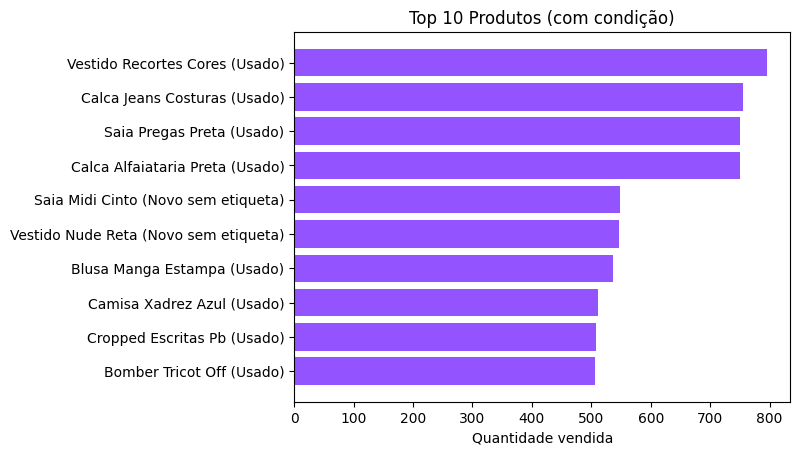

In [18]:
# Criar label combinando produto + condição
df_prod_quant['Label'] = df_prod_quant['produto'] + ' (' + df_prod_quant['Condicao'] + ')'

# Pegar os últimos 10 (como você já estava fazendo)
df_plot = df_prod_quant[-10:]

import matplotlib.pyplot as plt

plt.barh(df_plot['Label'], df_plot['Quantidade'], color='#9353FF')
plt.xlabel('Quantidade vendida')
plt.title('Top 10 Produtos (com condição)')
plt.show()

# 3. Lidando com filtro

In [20]:
sql_df('SELECT * FROM PEDIDOS').head(3)

,pedido_id,produto_id,vendedor_id,data_compra,total
0,341,41518,5,2019-01-05,780
1,1174,4307,3,2019-01-05,30875
2,1399,22407,1,2019-01-05,600


Vamos iniciar uma análise de desempenho do **time de vendedores** da Meteora. A intenção aqui é entender como se deram as vendas dos vendedores no **ano anterior** para que possam ser aplicadas promoções e bônus salarial para a equipe no ano atual da tabela que é 2021

In [19]:
sql_df('SELECT * FROM PEDIDOS').info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24527 entries, 0 to 24526
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   pedido_id    24527 non-null  int64 
 1   produto_id   24527 non-null  int64 
 2   vendedor_id  24527 non-null  int64 
 3   data_compra  24527 non-null  object
 4   total        24527 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 958.2+ KB


In [21]:
query = '''SELECT *
FROM PEDIDOS
WHERE strftime('%Y',data_compra) = '2020';
'''
sql_df(query)

,pedido_id,produto_id,vendedor_id,data_compra,total
0,112772,84743,3,2020-01-01,720
1,112909,56350,3,2020-01-01,1225
2,113068,70673,2,2020-01-01,1050
3,113453,16634,3,2020-01-01,2880
4,114487,43054,1,2020-01-01,640
...,...,...,...,...,...
14540,26762,9981,4,2020-12-31,8000
14541,27016,20029,3,2020-12-31,1764
14542,27666,12895,5,2020-12-31,10400
14543,28206,29893,4,2020-12-31,2100


In [22]:
query = '''SELECT VENDEDOR_ID, COUNT(*)
FROM PEDIDOS
WHERE strftime('%Y',data_compra) = '2020'
GROUP BY VENDEDOR_ID
'''
sql_df(query)

,vendedor_id,COUNT(*)
0,1,3427
1,2,3338
2,3,2782
3,4,2510
4,5,2488


In [23]:
## Selecionar dados do ano de 2019
query = '''
SELECT strftime('%m', data_compra) AS mes, COUNT(*) AS quantidade_vendas
FROM pedidos
WHERE strftime('%Y', data_compra) = '2019'
GROUP BY mes;
'''
vendas_19 = sql_df(query)
vendas_19

## Selecionar dados do ano de 2020
query = '''
SELECT strftime('%m', data_compra) AS mes, COUNT(*) AS quantidade_vendas
FROM pedidos
WHERE strftime('%Y', data_compra) = '2020'
GROUP BY mes;
'''
vendas_20 = sql_df(query)
vendas_20

,mes,quantidade_vendas
0,01,1271
1,02,1197
2,03,1280
3,04,1276
4,05,1206
5,06,896
6,07,984
7,08,1163
8,09,1221
9,10,1139


Para entender o desempenho de vendas dos vendedores no ano de 2019 e 2020, é preciso trabalhar com os dados que estão presentes apenas nos dois anos. 

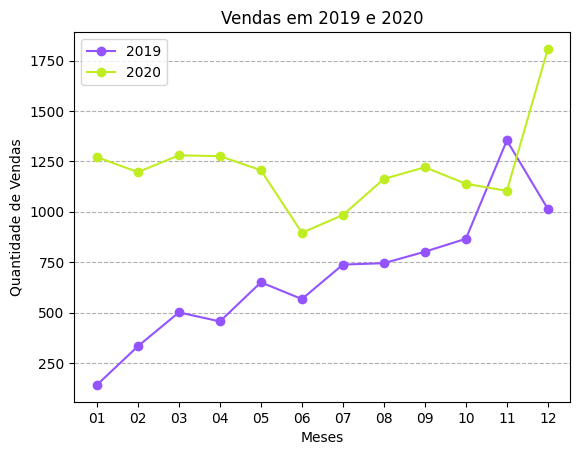

In [24]:
import matplotlib.pyplot as plt

plt.plot(vendas_19.mes.to_numpy(), vendas_19.quantidade_vendas.to_numpy(), marker='o', linestyle='-', color='#9353FF', label = '2019')
plt.plot(vendas_20.mes.to_numpy(), vendas_20.quantidade_vendas.to_numpy(), marker='o', linestyle='-', color='#C0ED22', label = '2020')

plt.title('Vendas em 2019 e 2020')
plt.xlabel('Meses')
plt.ylabel('Quantidade de Vendas')

plt.legend()

plt.grid(axis='y', linestyle='--')

plt.show()

In [25]:
print("Colunas Itens Pedidos:", itens_pedidos.columns.tolist())
print("Colunas Pedidos:", pedidos.columns.tolist())
print("Colunas Produtos:", produtos.columns.tolist())
print("Colunas Vendedores:", vendedores.columns.tolist())

Colunas Itens Pedidos: ['id_nf', 'produto_id', 'pedido_id', 'quantidade', 'valor_unitario', 'valor_total', 'Estado', 'frete']
Colunas Pedidos: ['pedido_id', 'produto_id', 'vendedor_id', 'data_compra', 'total']
Colunas Produtos: ['produto_id', 'produto', 'preco', 'marca', 'sku', 'Condicao']
Colunas Vendedores: ['vendedor_id', 'nome_vendedor']


In [26]:
query_vendedores_comp = """
SELECT v.nome_vendedor, COUNT(p.pedido_id) AS qtd_pedidos
FROM PEDIDOS p
JOIN VENDEDORES v ON p.vendedor_id = v.vendedor_id
WHERE p.data_compra LIKE '2019-12%'
GROUP BY v.nome_vendedor
"""
sql_df(query_vendedores_comp)

,nome_vendedor,qtd_pedidos
0,Ana Duarte,224
1,Daniel Siqueira,187
2,Millena Pereira,160
3,Nadia Oliveira,164
4,Paulo Calanca,279


In [27]:
query_vendedores_comp = """
SELECT v.nome_vendedor, COUNT(p.pedido_id) AS qtd_pedidos
FROM PEDIDOS p
JOIN VENDEDORES v ON p.vendedor_id = v.vendedor_id
WHERE p.data_compra LIKE '2019-12%'
GROUP BY v.nome_vendedor
"""
sql_df(query_vendedores_comp)

,nome_vendedor,qtd_pedidos
0,Ana Duarte,224
1,Daniel Siqueira,187
2,Millena Pereira,160
3,Nadia Oliveira,164
4,Paulo Calanca,279


In [28]:
# Dados de Dezembro 2019
query_2019 = """
SELECT v.nome_vendedor, COUNT(p.pedido_id) AS qtd_pedidos_2019
FROM PEDIDOS p
JOIN VENDEDORES v ON p.vendedor_id = v.vendedor_id
WHERE p.data_compra LIKE '2019-12%'
GROUP BY v.nome_vendedor
"""
df_2019 = sql_df(query_2019)

# Dados de Dezembro 2020
query_2020 = """
SELECT v.nome_vendedor, COUNT(p.pedido_id) AS qtd_pedidos_2020
FROM PEDIDOS p
JOIN VENDEDORES v ON p.vendedor_id = v.vendedor_id
WHERE p.data_compra LIKE '2020-12%'
GROUP BY v.nome_vendedor
"""
df_2020 = sql_df(query_2020)

In [29]:
# Unindo os dois dataframes pelo nome do vendedor
df_comparativo = pd.merge(df_2019, df_2020, on='nome_vendedor', how='outer').fillna(0)

# Criando uma coluna de diferença para análise rápida
df_comparativo['diferenca'] = df_comparativo['qtd_pedidos_2020'] - df_comparativo['qtd_pedidos_2019']

# Ordenando pelos que mais caíram para investigar o problema
df_comparativo.sort_values(by='diferenca', ascending=True)

,nome_vendedor,qtd_pedidos_2019,qtd_pedidos_2020,diferenca
0,Ana Duarte,224,229,5
4,Paulo Calanca,279,322,43
1,Daniel Siqueira,187,293,106
2,Millena Pereira,160,329,169
3,Nadia Oliveira,164,635,471


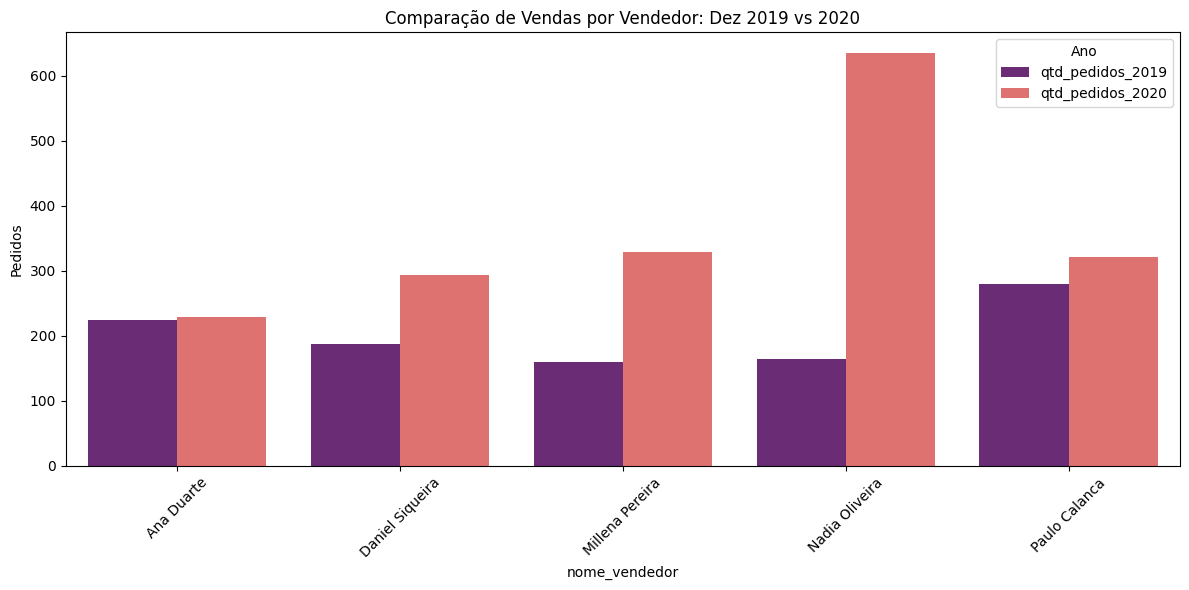

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Preparando os dados para o gráfico
df_plot = df_comparativo.melt(id_vars='nome_vendedor', 
                              value_vars=['qtd_pedidos_2019', 'qtd_pedidos_2020'],
                              var_name='Ano', value_name='Pedidos')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='nome_vendedor', y='Pedidos', hue='Ano', palette='magma')

plt.title('Comparação de Vendas por Vendedor: Dez 2019 vs 2020')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR, COUNT(PEDIDOS.PEDIDO_ID) AS 'Quantidade vendas'
FROM PEDIDOS, VENDEDORES
WHERE strftime('%Y',data_compra) = '2020' AND VENDEDORES.VENDEDOR_ID = PEDIDOS.VENDEDOR_ID
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY COUNT(PEDIDOS.PEDIDO_ID) DESC;
'''
sql_df(query)

,nome_vendedor,Quantidade vendas
0,Ana Duarte,3427
1,Daniel Siqueira,3338
2,Nadia Oliveira,2782
3,Millena Pereira,2510
4,Paulo Calanca,2488


In [32]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR, AVG(PEDIDOS.TOTAL) AS 'Valor médio por vendas'
FROM PEDIDOS, VENDEDORES
WHERE strftime('%Y',data_compra) = '2020' AND VENDEDORES.VENDEDOR_ID = PEDIDOS.VENDEDOR_ID
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY AVG(PEDIDOS.TOTAL) DESC;
'''
sql_df(query)

,nome_vendedor,Valor médio por vendas
0,Daniel Siqueira,1972.338526
1,Millena Pereira,1894.614343
2,Ana Duarte,1843.452582
3,Nadia Oliveira,1818.342200
4,Paulo Calanca,1813.469855


# 4. Avançando nas relações

A Meteora agora deseja incrementar as suas vendas no **estado de São Paulo (SP)**, por acreditar ser uma região mais propícia às vendas já que tem uma boa concentração de pessoas e mercado também.

Mas será que São Paulo já não rende muitas vendas em relação a outros estados?

In [33]:
query_estados = """
SELECT ESTADO, COUNT(*) AS Pedidos
FROM ITENS_PEDIDOS
GROUP BY ESTADO
ORDER BY Pedidos DESC
"""

df_estados = sql_df(query_estados)

df_estados

,Estado,Pedidos
0,BR-MA,974
1,BR-DF,953
2,BR-MT,937
3,BR-GO,933
4,BR-PA,932
5,BR-AL,928
6,BR-PE,927
7,BR-RR,925
8,BR-RO,925
9,BR-RN,921


In [53]:
query_ticket_estado = '''
SELECT 
    ITENS_PEDIDOS.Estado, 
    AVG(PEDIDOS.total) AS 'Ticket Medio'
FROM PEDIDOS
JOIN ITENS_PEDIDOS ON PEDIDOS.pedido_id = ITENS_PEDIDOS.pedido_id
GROUP BY ITENS_PEDIDOS.Estado
ORDER BY AVG(PEDIDOS.total) DESC;
'''
df_ticket_medio = sql_df(query_ticket_estado)
sql_df(query_ticket_estado)

,Estado,Ticket Medio
0,BR-AP,2113.026346
1,BR-SC,2083.750564
2,BR-CE,2078.257078
3,BR-AL,2050.129310
4,BR-PE,2035.056095
5,BR-SP,1972.488764
6,BR-PB,1938.772331
7,BR-GO,1900.061093
8,BR-MA,1864.809035
9,BR-BA,1849.157718


In [54]:
import plotly.express as px

# 1. Criamos uma lista de cores: cinza para todos, laranja para SP
cores = ['orange' if estado == 'BR-SP' else 'lightgray' for estado in df_ticket_medio['Estado']]

# 2. Geramos o gráfico
fig = px.bar(df_ticket_medio, 
             x='Estado', 
             y='Ticket Medio',
             title='Ticket Médio por Estado: São Paulo em 5º Lugar',
             labels={'Ticket Medio': 'Valor Médio (R$)', 'Estado': 'UF'},
             text_auto='.2f')

# 3. Aplicamos as cores que criamos no passo 1
fig.update_traces(marker_color=cores, showlegend=False)

# 4. Ajustes finais de layout
fig.update_layout(xaxis_tickangle=-45, template='plotly_white')

fig.show()

Uma das ações que a Meteora pretende seguir para as vendas em SP é escolher dois de seus vendedores para que eles **foquem suas vendas** lá. Para essa escolha é interessante ter os profissionais que **mais tenham vendido** para as pessoas da região.

In [34]:
query_vendedores_plus = '''SELECT PEDIDOS.VENDEDOR_ID, COUNT(*) AS quantidade_vendas
FROM PEDIDOS
JOIN ITENS_PEDIDOS ON ITENS_PEDIDOS.PEDIDO_ID = PEDIDOS.PEDIDO_ID
WHERE ITENS_PEDIDOS.ESTADO = 'BR-SP'
GROUP BY PEDIDOS.VENDEDOR_ID
ORDER BY quantidade_vendas DESC;
'''
sql_df(query_vendedores_plus)

,vendedor_id,quantidade_vendas
0,2,190
1,5,182
2,3,181
3,1,180
4,4,157


In [35]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR, COUNT(*) AS quantidade_vendas, estado
FROM PEDIDOS
JOIN VENDEDORES ON VENDEDORES.VENDEDOR_ID = PEDIDOS.VENDEDOR_ID
JOIN ITENS_PEDIDOS ON ITENS_PEDIDOS.PEDIDO_ID = PEDIDOS.PEDIDO_ID
WHERE ITENS_PEDIDOS.ESTADO = 'BR-SP'
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY quantidade_vendas DESC;
'''
sql_df(query)

,nome_vendedor,quantidade_vendas,Estado
0,Daniel Siqueira,190,BR-SP
1,Paulo Calanca,182,BR-SP
2,Nadia Oliveira,181,BR-SP
3,Ana Duarte,180,BR-SP
4,Millena Pereira,157,BR-SP


Colunas encontradas: ['nome_vendedor', 'quantidade_vendas', 'Estado']


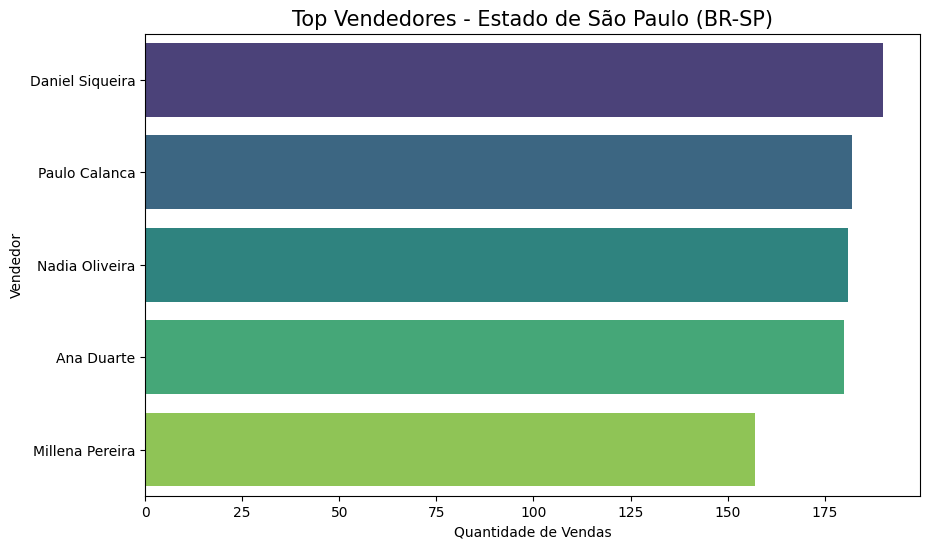

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Executa a query
df_vendas_sp = sql_df(query)

# 2. Verificação de colunas (bom para conferir se o SQL trouxe o que você esperava)
print("Colunas encontradas:", df_vendas_sp.columns.tolist())

# 3. Configura o tamanho da figura
plt.figure(figsize=(10, 6))

# Pegando os nomes das colunas dinamicamente para evitar o erro de 'coluna não encontrada'
coluna_vendedor = df_vendas_sp.columns[0]  
coluna_vendas = df_vendas_sp.columns[1]    

# 4. Criação do gráfico com as correções para as versões novas do Seaborn
sns.barplot(
    data=df_vendas_sp, 
    x=coluna_vendas, 
    y=coluna_vendedor, 
    palette='viridis',
    hue=coluna_vendedor, # Define que a cor segue o vendedor (evita o aviso)
    legend=False         # Remove a legenda lateral que ficaria duplicada
)

# 5. Finalização com títulos e exibição
plt.title('Top Vendedores - Estado de São Paulo (BR-SP)', fontsize=15)
plt.xlabel('Quantidade de Vendas')
plt.ylabel('Vendedor')
plt.show()